In [1]:
from Simulation.mpc import *
from Simulation.system_functions import PolymerCSTR
from utils.helpers import *

# Initializing The system

In [2]:
# First initiate the system
# Parameters
Ad = 2.142e17           # h^-1
Ed = 14897              # K
Ap = 3.816e10           # L/(molh)
Ep = 3557               # K
At = 4.50e12            # L/(molh)
Et = 843                # K
fi = 0.6                # Coefficient
m_delta_H_r = -6.99e4   # j/mol
hA = 1.05e6             # j/(Kh)
rhocp = 1506            # j/(Kh)
rhoccpc = 4043          # j/(Kh)
Mm = 104.14             # g/mol
system_params = np.array([Ad, Ed, Ap, Ep, At, Et, fi, m_delta_H_r, hA, rhocp, rhoccpc, Mm])

In [3]:
# Design Parameters
CIf = 0.5888    # mol/L
CMf = 8.6981    # mol/L
Qi = 108.       # L/h
Qs = 459.       # L/h
Tf = 330.       # K
Tcf = 295.      # K
V = 3000.       # L
Vc = 3312.4     # L

system_design_params = np.array([CIf, CMf, Qi, Qs, Tf, Tcf, V, Vc])

In [4]:
# Steady State Inputs
Qm_ss = 378.    # L/h
Qc_ss = 471.6   # L/h

system_steady_state_inputs = np.array([Qc_ss, Qm_ss])

In [5]:
# Sampling time of the system
delta_t = 0.5 # 30 mins

In [6]:
# Initiate the CSTR for steady state values
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)
steady_states={"ss_inputs":cstr.ss_inputs,
               "y_ss":cstr.y_ss}

## Loading the system matrices, min max scaling, and min max of the states

In [7]:
dir_path = os.path.join(os.getcwd(), "Data")

In [8]:
# Defining the range of setpoints for data generation
setpoint_y = np.array([[2.8, 320.],
                       [5., 326.]])
u_min = np.array([71.6, 78])
u_max = np.array([870, 670])

system_data = load_and_prepare_system_data(steady_states=steady_states, setpoint_y=setpoint_y, u_min=u_min, u_max=u_max)

In [9]:
A_aug = system_data["A_aug"]
B_aug = system_data["B_aug"]
C_aug = system_data["C_aug"]

In [10]:
data_min = system_data["data_min"]
data_max = system_data["data_max"]

In [11]:
# min_max_states = system_data["min_max_states"]
# min_max_states = system_data["min_max_states"]
min_max_states = {'max_s': np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ]),
                  'min_s': np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])}

In [12]:
y_sp_scaled_deviation = system_data["y_sp_scaled_deviation"]

In [13]:
b_min = system_data["b_min"]
b_max = system_data["b_max"]

In [14]:
min_max_dict = system_data["min_max_dict"]
min_max_dict["x_max"] = np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ])
min_max_dict["x_min"] = np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])

In [15]:
# Observer Gain
poles = np.array(np.array([0.44619852, 0.33547649, 0.36380595, 0.70467118, 0.3562966,
                           0.42900673, 0.4228262 , 0.96916776, 0.91230187]))
L = compute_observer_gain(A_aug, C_aug, poles)

The system is observable.


C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\RL_assisted_MPC_polymer\Simulation\mpc.py:124: UserWarning: Convergence was not reached after maxiter iterations.
You asked for a tolerance of 0.001, we got 0.9999999422182039.
  obs_gain_calc = signal.place_poles(A.T, C.T, desired_poles, method='KNV0')


# DQN network

In [16]:
from DQN.dqn_agent import DQNAgent
import torch

In [17]:
PREDICT_GRID = list(range(8, 20))  # Hp candidates
CONTROL_GRID = list(range(3, 10))     # Hc candidates (will be filtered by Hc <= Hp)

In [18]:
HORIZON_RECIPES = build_horizon_recipes(PREDICT_GRID, CONTROL_GRID)
N_ACTIONS = len(HORIZON_RECIPES)

In [19]:
STATE_DIM = int(A_aug.shape[0]) + int(C_aug.shape[0]) + int(B_aug.shape[1])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
HIDDEN_LAYERS = [512, 512, 512, 512]
BUFFER_SIZE = 300_000
DECISION_INTERVAL = 5
INPUT_NUMBER = B_aug.shape[1]

Using device: cuda


In [20]:
dqn_agent = DQNAgent(
    state_dim=STATE_DIM,
    action_dim=N_ACTIONS,
    hidden_dim=HIDDEN_LAYERS,
    gamma=0.99,
    lr=1e-3,
    batch_size=128,
    buffer_size=BUFFER_SIZE,
    grad_clip_norm=10.0,
    double_dqn=True,
    target_update="soft",
    tau=0.01,
    hard_update_interval=10_000,
    target_combine="q1",
    activation="relu",
    use_layer_norm=False,
    dropout=0.0,
    device=DEVICE,
    eps_start=0.2,
    eps_end=0.01,
    eps_decay_rate=0.99995,
    eps_decay_mode="exp",
)

In [21]:
# MPC parameters
predict_h = 9
cont_h = 3
Q1_penalty = 5
Q2_penalty = 1
R1_penalty = 1
R2_penalty = 1
Q_penalty = np.array([[Q1_penalty, 0], [0, Q2_penalty]])
R_penalty = np.array([[R1_penalty, 0], [0, R2_penalty]])

In [22]:
y_sp_scenario = np.array([[4.5, 324],
                          [3.4, 321]])

# y_sp_scenario = np.concatenate((steady_states["y_ss"].reshape(1, -1), y_sp_scenario), axis=0)


y_sp_scenario = apply_min_max(y_sp_scenario, data_min[2:], data_max[2:]) - apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
n_tests = 200
set_points_len = 400
TEST_CYCLE = [False, False, False, False, False]
warm_start = 0

In [23]:
nominal_qs = 459
nominal_qi = 108
nominal_hA = 1.05e6
qi_change = 0.95
qs_change = 1.05
ha_change = 0.92

In [24]:
def run_dqn_mpc_horizon_supervisor(system, y_sp_scenario, n_tests, set_points_len,
                 steady_states, min_max_dict, agent, A_aug, B_aug, C_aug,
                 Q1_penalty, Q2_penalty, R1_penalty, R2_penalty, L,
                 data_min, data_max, warm_start, test_cycle,
                 nominal_qi, nominal_qs, nominal_ha,
                 qi_change, qs_change, ha_change,
                 h_recipes,
                 b_min, b_max, predict_h = 9, cont_h = 3):

    # --- setpoints generation ---
    y_sp, nFE, sub_episodes_changes_dict, time_in_sub_episodes, test_train_dict, WARM_START, qi, qs, ha = \
        generate_setpoints_training_rl_gradually(
            y_sp_scenario, n_tests, set_points_len, warm_start, test_cycle,
            nominal_qi, nominal_qs, nominal_ha,
            qi_change, qs_change, ha_change
        )

    # inputs and outputs of the system dimensions
    n_inputs = B_aug.shape[1]
    n_outputs = C_aug.shape[0]
    n_states = A_aug.shape[0]

    # Scaled steady states inputs and outputs
    ss_scaled_inputs = apply_min_max(steady_states["ss_inputs"], data_min[:n_inputs], data_max[:n_inputs])
    y_ss_scaled = apply_min_max(steady_states["y_ss"], data_min[n_inputs:], data_max[n_inputs:])

    # Logging
    y_system = np.zeros((nFE + 1, n_outputs))
    y_system[0, :] = system.current_output
    u_mpc = np.zeros((nFE, n_inputs))
    rewards = np.zeros(nFE)
    avg_rewards = []
    yhat = np.zeros((n_outputs, nFE))
    xhatdhat = np.zeros((n_states, nFE + 1))
    xhatdhat[:, 0] = np.random.uniform(low=min_max_dict["x_min"], high=min_max_dict["x_max"])
    horizon_trace = np.zeros((nFE, 2), dtype=int)

    # # Reward params (your shaping)
    # band   = np.array([0.02, 0.02], dtype=float)
    # Q_diag = np.array([Q1_penalty, Q2_penalty], dtype=float)
    # R_diag = np.array([R1_penalty, R2_penalty], dtype=float)

    # --- MPC object: start with some default recipe ---
    last_a = None
    current_Hp, current_Hc = (predict_h, cont_h)
    MPC_obj = MpcSolver(A_aug, B_aug, C_aug,
                        Q1_penalty, Q2_penalty, R1_penalty, R2_penalty,
                        current_Hp, current_Hc)

    # Bounds and constraints
    b1 = (b_min[0], b_max[0])
    b2 = (b_min[1], b_max[1])
    cons = []

    # Helper to rebuild solver when Hc/Hp change
    def rebuild_mpc(Hp: int, Hc: int):
        nonlocal MPC_obj
        MPC_obj = MpcSolver(A_aug, B_aug, C_aug,
                            Q1_penalty, Q2_penalty, R1_penalty, R2_penalty,
                            Hp, Hc)

    for i in range(nFE):
        # Identify test or train phase
        # train/test phase
        if i in test_train_dict:
            test = test_train_dict[i]

        # Current scaled input & deviation
        scaled_current_input = apply_min_max(system.current_input, data_min[:n_inputs], data_max[:n_inputs])
        scaled_current_input_dev = scaled_current_input - ss_scaled_inputs

        # ---- DQN state ----
        current_rl_state = apply_rl_scaled(min_max_dict, xhatdhat[:, i], y_sp[i, :], scaled_current_input_dev)

        # ---- Choose action (horizons) occasionally ----
        if (i % DECISION_INTERVAL == 0) or (last_a is None):
            a_idx = agent.take_action(current_rl_state.astype(np.float32), eval_mode=test)
            Hp, Hc = action_to_horizons(h_recipes, a_idx)
            # Rebuild MPC only if changed
            if (Hp, Hc) != (current_Hp, current_Hc):
                rebuild_mpc(Hp, Hc)
                current_Hp, current_Hc = Hp, Hc
            last_a = a_idx
        else:
            a_idx = last_a
            Hp, Hc = current_Hp, current_Hc

        horizon_trace[i] = (Hp, Hc)

        # ---- Solve MPC with current horizons ----
        # Bounds and initial guess must match current Hc
        bnds  = (b1, b2) * Hc
        IC_opt = np.zeros(n_inputs * Hc)

        sol = spo.minimize(
            lambda x: MPC_obj.mpc_opt_fun(x, y_sp[i, :], scaled_current_input_dev, xhatdhat[:, i]),
            IC_opt, bounds=bnds, constraints=cons
        )

        # Take first move (scaled deviation) and map to plant input
        u_mpc[i, :] = sol.x[:n_inputs] + ss_scaled_inputs
        u_plant = reverse_min_max(u_mpc[i, :], data_min[:n_inputs], data_max[:n_inputs])

        # delta u cost variables
        delta_u = u_mpc[i, :] - scaled_current_input

        # Apply to plant and step
        system.current_input = u_plant
        system.step()
        # disturbances
        system.hA = ha[i]
        system.Qs = qs[i]
        system.Qi = qi[i]

        # Record output
        y_system[i+1, :] = system.current_output

        # ----- Observer & model roll -----
        y_current_scaled = apply_min_max(y_system[i+1, :], data_min[n_inputs:], data_max[n_inputs:]) - y_ss_scaled
        y_prev_scaled = apply_min_max(y_system[i, :], data_min[n_inputs:], data_max[n_inputs:]) - y_ss_scaled

        # Calculate Delta y in deviation form
        delta_y = y_current_scaled - y_sp[i, :]

        # Calculate the next state in deviation form
        yhat[:, i] = np.dot(MPC_obj.C, xhatdhat[:, i])
        xhatdhat[:, i+1] = np.dot(MPC_obj.A, xhatdhat[:, i]) + np.dot(MPC_obj.B, (u_mpc[i, :] - ss_scaled_inputs)) + np.dot(L, (y_prev_scaled - yhat[:, i])).T

        # Reward Calculation
        reward = - (Q1_penalty * delta_y[0] ** 2 + Q2_penalty * delta_y[1] ** 2 +
                    R1_penalty * delta_u[0] ** 2 + R2_penalty * delta_u[1] ** 2)

        # Record rewards
        rewards[i] = reward

        # ----- Next state for DQN -----
        next_u_dev = u_mpc[i, :] - ss_scaled_inputs
        next_rl_state = apply_rl_scaled(min_max_dict, xhatdhat[:, i+1], y_sp[i, :], next_u_dev)

        # Episode boundary (treat each setpoint block as an episode end)
        done = ((i + 1) % time_in_sub_episodes == 0) or (i == nFE - 1)

        # Buffer + train (skip if in test phase)
        if not test:
            agent.push(current_rl_state.astype(np.float32),
                       int(a_idx),
                       float(reward),
                       next_rl_state.astype(np.float32),
                       float(done))
            if i >= WARM_START:
                _ = agent.train_step()  # returns loss or None

        # Print diagnostics on sub-episode boundary
        if i in sub_episodes_changes_dict:
            avg_rewards.append(np.mean(rewards[max(0, i - time_in_sub_episodes + 1): i + 1]))
            print('Sub_Episode:', sub_episodes_changes_dict[i], '| avg. reward:', avg_rewards[-1],
                  '| Hp,Hc:', (Hp, Hc))

    # Reverse scaling for RL inputs
    u_rl = reverse_min_max(u_mpc, data_min[:n_inputs], data_max[:n_inputs])

    return (y_system, u_rl, avg_rewards, rewards, xhatdhat, nFE, time_in_sub_episodes,
            y_sp, yhat,
            qi, qs, ha, horizon_trace)

In [25]:
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)
(y_system, u_rl, avg_rewards, rewards, xhatdhat, nFE, time_in_sub_episodes,
y_sp, yhat,
qi, qs, ha, horizon_trace) = run_dqn_mpc_horizon_supervisor(cstr, y_sp_scenario, n_tests, set_points_len,
                 steady_states, min_max_dict, dqn_agent, A_aug, B_aug, C_aug,
                 Q1_penalty, Q2_penalty, R1_penalty, R2_penalty, L,
                 data_min, data_max, warm_start, TEST_CYCLE,
                 nominal_qi, nominal_qs, nominal_hA,
                 qi_change, qs_change, ha_change,
                 HORIZON_RECIPES,
                 b_min, b_max, predict_h = 9, cont_h = 3)

Sub_Episode: 1 | avg. reward: -2.4002099052054358 | Hp,Hc: (18, 8)
Sub_Episode: 2 | avg. reward: -3.0378763208768387 | Hp,Hc: (18, 5)
Sub_Episode: 3 | avg. reward: -3.277203051130348 | Hp,Hc: (12, 8)
Sub_Episode: 4 | avg. reward: -3.5045599821645923 | Hp,Hc: (15, 3)
Sub_Episode: 5 | avg. reward: -3.0472392605842735 | Hp,Hc: (13, 8)
Sub_Episode: 6 | avg. reward: -3.4297731725300697 | Hp,Hc: (17, 7)
Sub_Episode: 7 | avg. reward: -2.99048145115888 | Hp,Hc: (9, 9)
Sub_Episode: 8 | avg. reward: -3.0168634127751814 | Hp,Hc: (13, 3)
Sub_Episode: 9 | avg. reward: -2.8668866263547805 | Hp,Hc: (11, 8)
Sub_Episode: 10 | avg. reward: -2.8267711459607114 | Hp,Hc: (14, 5)
Sub_Episode: 11 | avg. reward: -3.2354989558059644 | Hp,Hc: (16, 8)
Sub_Episode: 12 | avg. reward: -3.371091412287699 | Hp,Hc: (13, 9)
Sub_Episode: 13 | avg. reward: -3.2369204370698292 | Hp,Hc: (15, 5)
Sub_Episode: 14 | avg. reward: -3.6053078980667954 | Hp,Hc: (10, 7)
Sub_Episode: 15 | avg. reward: -3.398746367828297 | Hp,Hc: (9,

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rl_results_dqn(
    y_sp,
    steady_states,
    nFE,
    delta_t,
    time_in_sub_episodes,
    y_mpc,
    u_mpc,
    avg_rewards,
    data_min, data_max,
    horizon_trace=None,
    recipe_counts=False,
    mpc_baseline=None  # tuple (Hp0, Hc0) to highlight in red in the bar chart
):
    """
    Presentation-ready plots:
      - Legends removed.
      - Bold, readable labels and ticks.
      - Histogram highlights the (Hp,Hc) == mpc_baseline bar in red.
    """

    # --- Presentation style ---
    plt.rcParams.update({
        "font.size": 16,
        "axes.labelsize": 20,
        "axes.labelweight": "bold",
        "axes.titlesize": 22,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "mathtext.default": "regular"
    })
    LW, MS = 3.0, 6

    def _style(ax, xlabel=None, ylabel=None):
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=20, fontweight='bold')
        ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.tick_params(axis='both', labelsize=16)
        ax.margins(x=0.01)

    # --- Unscale setpoints back to original units ---
    y_ss = apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
    y_sp_full = reverse_min_max(y_sp + y_ss, data_min[2:], data_max[2:]).T  # [ny, nFE]

    # --- Time axes ---
    time_full    = np.linspace(0, nFE * delta_t, nFE + 1)                # outputs
    time_full_u  = np.linspace(0, (nFE-1) * delta_t, nFE)                # inputs
    time_block   = np.linspace(0, time_in_sub_episodes * delta_t, time_in_sub_episodes + 1)
    time_block_u = np.linspace(0, (time_in_sub_episodes-1) * delta_t, time_in_sub_episodes)
    s0 = nFE - time_in_sub_episodes

    # 1) Outputs vs Setpoints (full)
    fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
    axs[0].plot(time_full, y_mpc[:, 0], lw=LW)
    axs[0].step(time_full[:-1], y_sp_full[0, :], where='post', linestyle='--', lw=LW)
    _style(axs[0], ylabel=r'$\mathbf{\eta}$ (L/g)')

    axs[1].plot(time_full, y_mpc[:, 1], lw=LW)
    axs[1].step(time_full[:-1], y_sp_full[1, :], where='post', linestyle='--', lw=LW)
    _style(axs[1], xlabel=r'$\mathbf{Time}$ (hour)', ylabel=r'$\mathbf{T}$ (K)')
    fig.tight_layout(); plt.show()

    # 2) Outputs vs Setpoints (last block)
    fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
    axs[0].plot(time_block, y_mpc[s0:, 0], lw=LW)
    axs[0].step(time_block[:-1], y_sp_full[0, s0:], where='post', linestyle='--', lw=LW)
    _style(axs[0], ylabel=r'$\mathbf{\eta}$ (L/g)')

    axs[1].plot(time_block, y_mpc[s0:, 1], lw=LW)
    axs[1].step(time_block[:-1], y_sp_full[1, s0:], where='post', linestyle='--', lw=LW)
    _style(axs[1], xlabel=r'$\mathbf{Time}$ (hour)', ylabel=r'$\mathbf{T}$ (K)')
    fig.tight_layout(); plt.show()

    # 3) Inputs (Qc, Qm)
    fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
    axs[0].step(time_full_u, u_mpc[:, 0], where='post', lw=LW)
    _style(axs[0], ylabel=r'$\mathbf{Q}_c$ (L/h)')

    axs[1].step(time_full_u, u_mpc[:, 1], where='post', lw=LW)
    _style(axs[1], xlabel=r'$\mathbf{Time}$ (hour)', ylabel=r'$\mathbf{Q}_m$ (L/h)')
    fig.tight_layout(); plt.show()

    # 4) Average reward per block
    plt.figure(figsize=(10, 7))
    plt.plot(np.arange(1, len(avg_rewards) + 1), avg_rewards, 'o-', lw=LW, markersize=MS)
    plt.ylabel(r'Avg.\ Reward', fontsize=20, fontweight='bold')
    plt.xlabel(r'Episode\ #}', fontsize=20, fontweight='bold')
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.tight_layout(); plt.show()

    # 5) Horizons (Hp, Hc)
    if horizon_trace is not None:
        Hp = horizon_trace[:, 0].astype(int)
        Hc = horizon_trace[:, 1].astype(int)

        # Full timeline
        fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
        axs[0].step(time_full_u, Hp, where='post', lw=LW)
        _style(axs[0], ylabel='Prediction Horizon (steps)')

        axs[1].step(time_full_u, Hc, where='post', lw=LW)
        _style(axs[1], xlabel='Time (hour)', ylabel='Control Horizon (steps)')
        fig.tight_layout(); plt.show()

        # Last block
        fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
        axs[0].step(time_block_u, Hp[s0:], where='post', lw=LW)
        _style(axs[0], ylabel='Prediction Horizon (steps)')

        axs[1].step(time_block_u, Hc[s0:], where='post', lw=LW)
        _style(axs[1], xlabel='Time (hour)', ylabel='Control Horizon (steps)')
        fig.tight_layout(); plt.show()

        # Optional usage histogram (top 20)
        if recipe_counts:
            import collections
            counts = collections.Counter(list(zip(Hp, Hc)))
            pairs, freqs = zip(*sorted(counts.items(), key=lambda x: (-x[1], x[0])))

            top_k = 20
            pairs, freqs = pairs[:top_k], freqs[:top_k]

            # Default gray; highlight mpc_baseline in red if present
            colors = ['0.5'] * len(freqs)
            if mpc_baseline is not None:
                for i, p in enumerate(pairs):
                    if (p[0] == mpc_baseline[0]) and (p[1] == mpc_baseline[1]):
                        colors[i] = 'red'

            x = np.arange(len(freqs))
            plt.figure(figsize=(12, 7))
            plt.bar(x, freqs, color=colors, edgecolor='black', linewidth=1.0)
            labels = [f"Hp={p[0]}, Hc={p[1]}" for p in pairs]
            plt.xticks(x, labels, rotation=35, ha='right', fontsize=16, fontweight='bold')
            plt.ylabel('Count', fontsize=20, fontweight='bold')
            plt.title('Horizon Pair Usage', fontsize=22, fontweight='bold')
            plt.grid(axis='y', linestyle='--', alpha=0.5)
            plt.tight_layout(); plt.show()


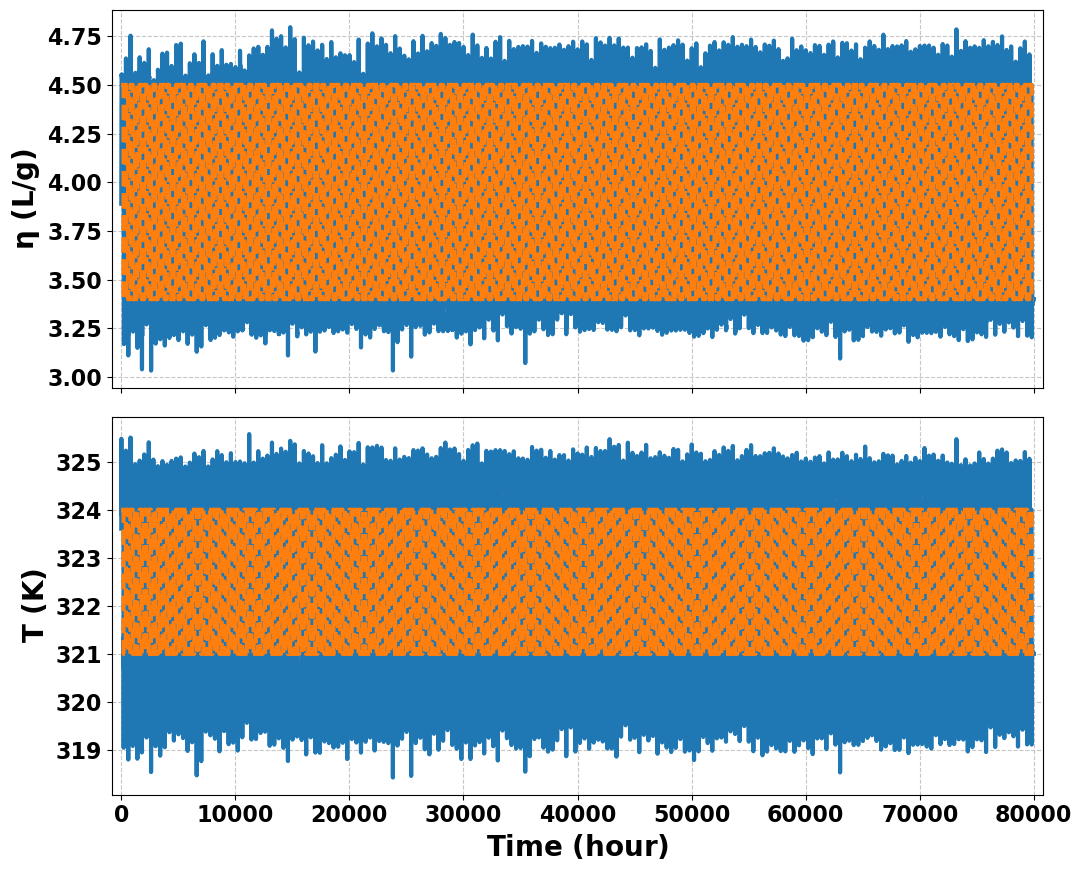

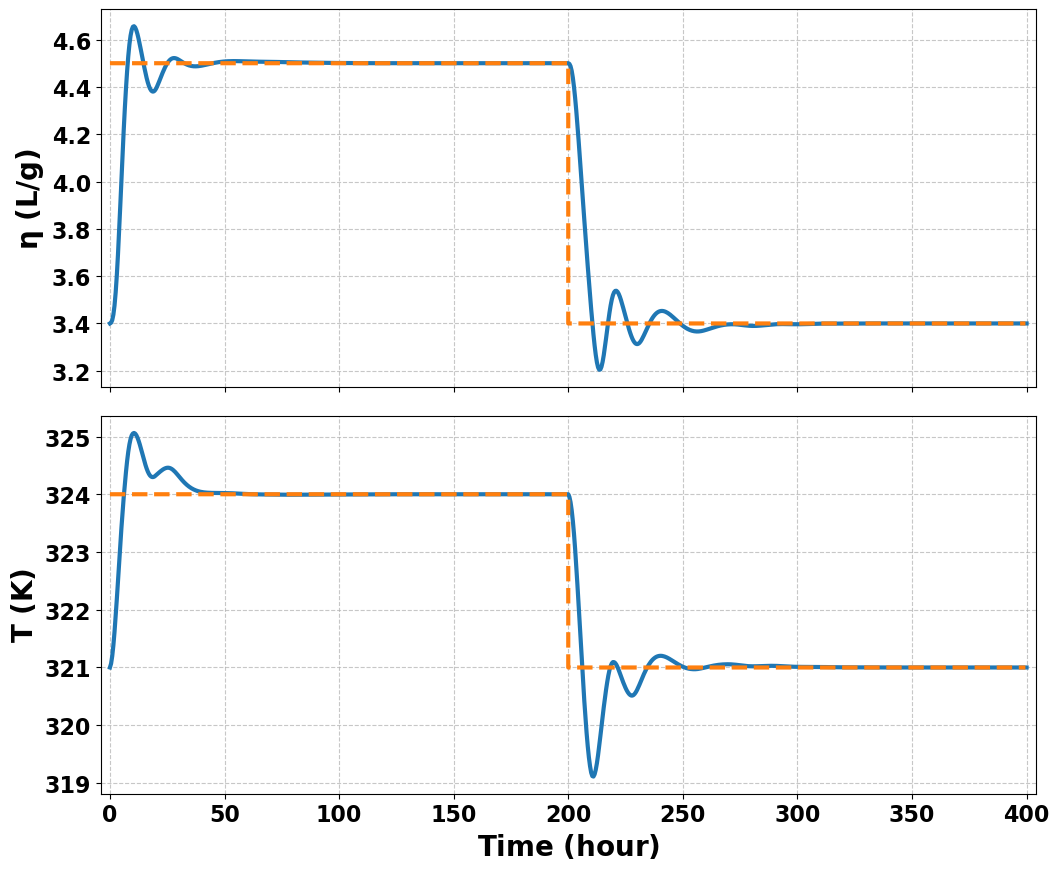

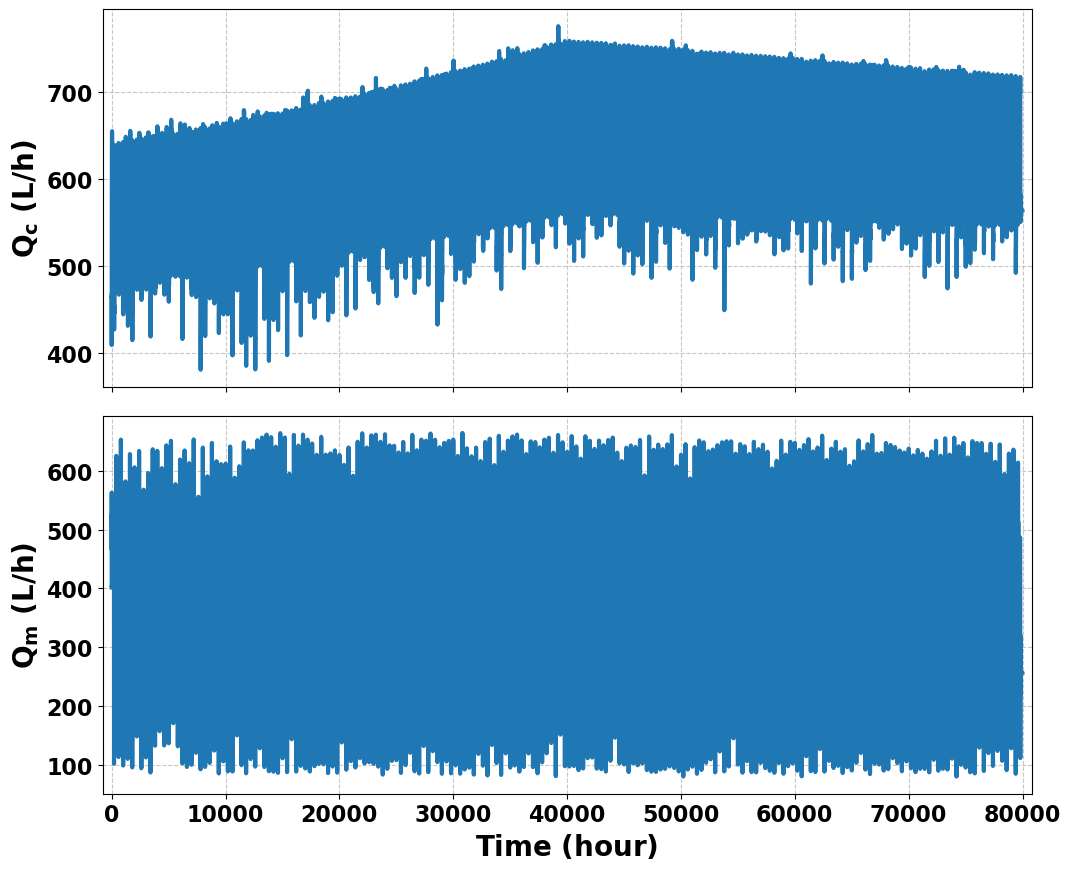

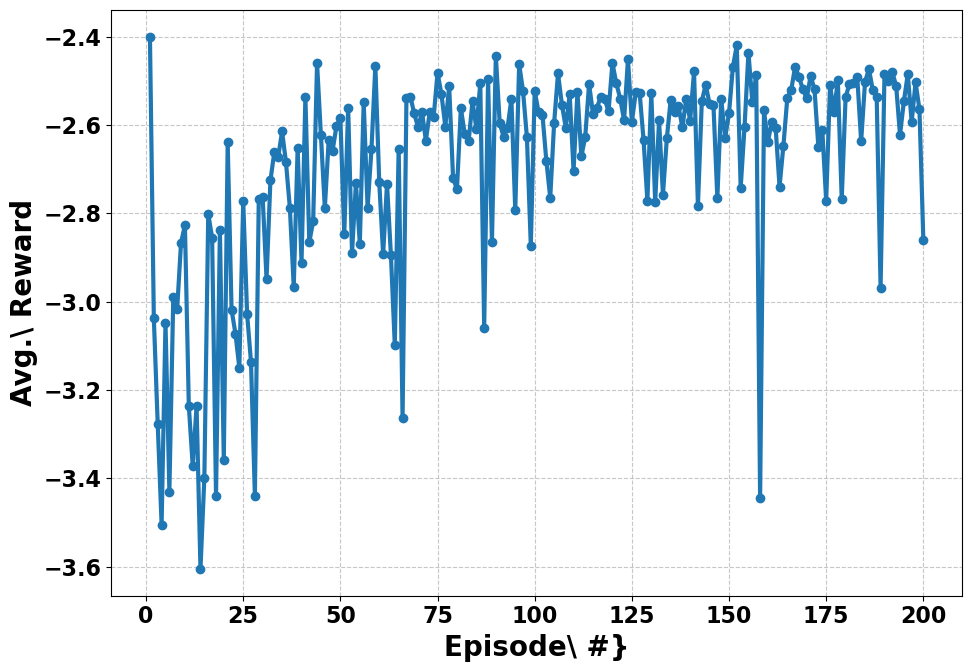

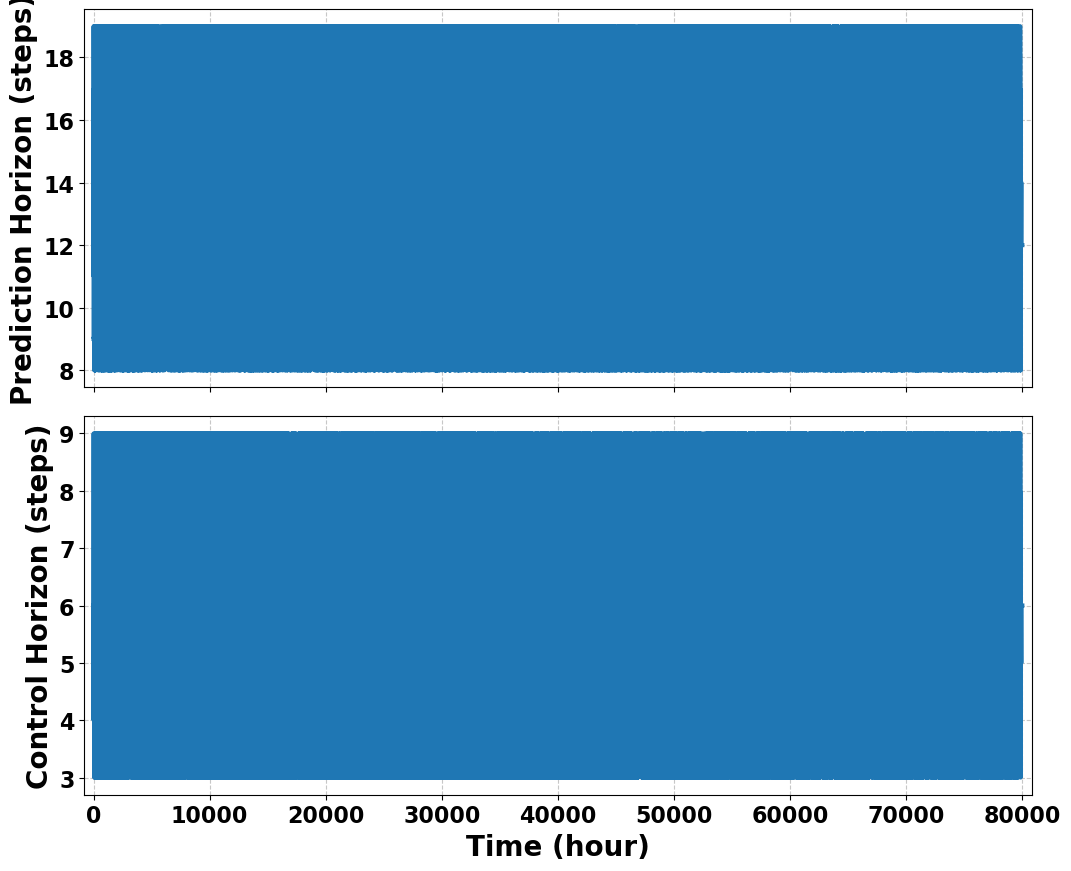

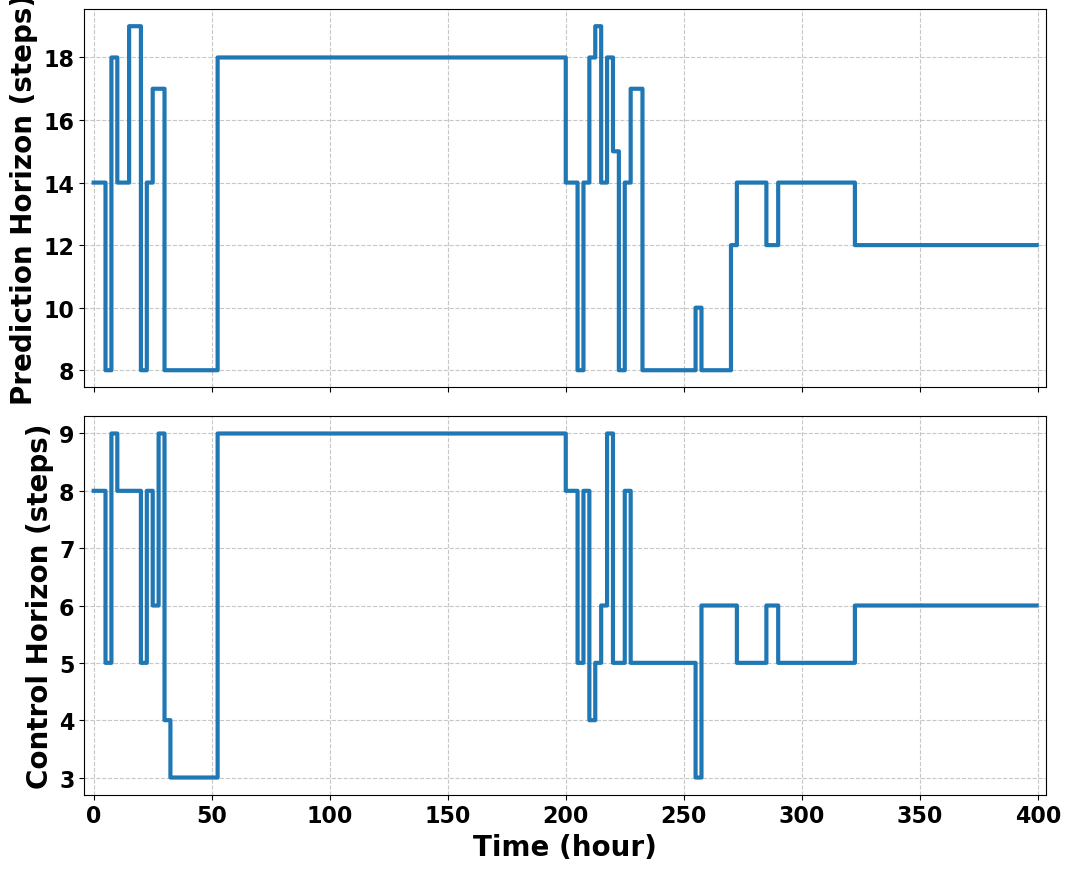

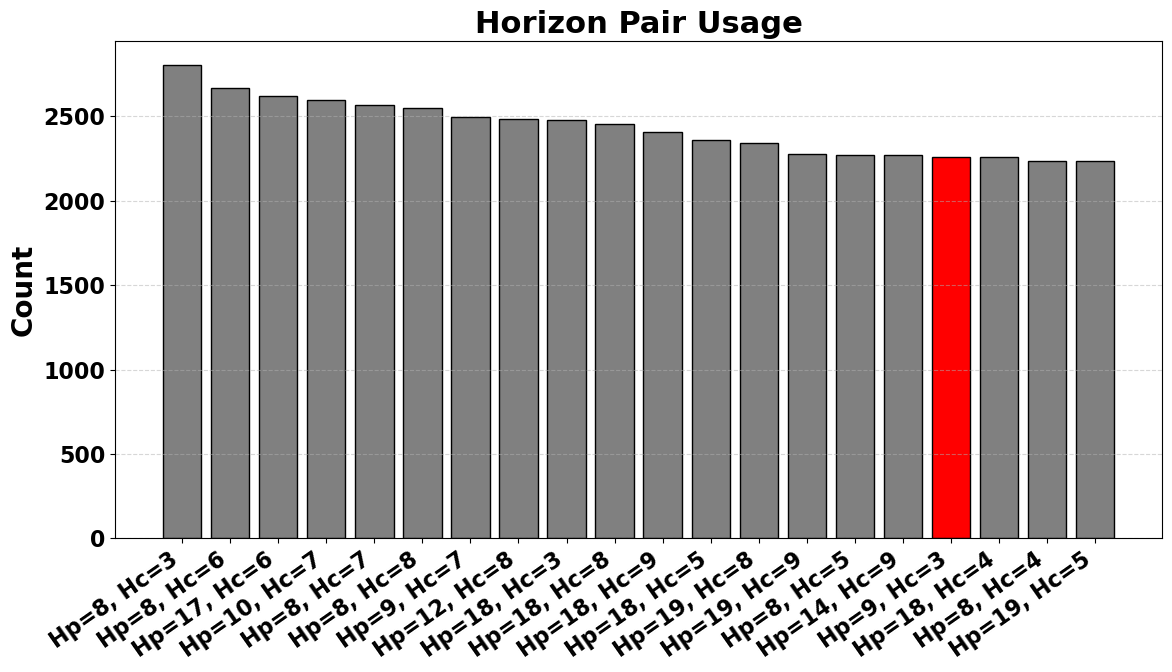

In [45]:
plot_rl_results_dqn(
    y_sp=y_sp,                      # from run
    steady_states=steady_states,
    nFE=nFE,
    delta_t=delta_t,
    time_in_sub_episodes=time_in_sub_episodes,
    y_mpc=y_system,                 # plant outputs (nFE+1, 2)
    u_mpc=u_rl,                     # plant inputs in L/h (nFE, 2)
    avg_rewards=avg_rewards,
    data_min=data_min,
    data_max=data_max,
    horizon_trace=horizon_trace,    # (nFE, 2)
    recipe_counts=True,              # turn on histogram (optional)
    mpc_baseline=(predict_h, cont_h)
)

In [71]:
def compare_mpc_rl_disturbance(y_rl, y_mpc, y_sp, avg_rewards_rl, avg_rewards_mpc, time_in_sub_episodes, delta_t):

    y_ss = apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
    y_sp = (y_sp + y_ss)
    y_sp = (reverse_min_max(y_sp, data_min[2:], data_max[2:]))

    # --- Plot the "last portion" (time_in_sub_episodes) ---
    # Convert those steps to their own time axis
    time_plot_sub = np.linspace(0, time_in_sub_episodes * delta_t, time_in_sub_episodes)
    s0 = -800

        # --- Global presentation style ---
    plt.rcParams.update({
        "font.size": 16,
        "axes.labelsize": 20,
        "axes.labelweight": "bold",
        "axes.titlesize": 22,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "mathtext.default": "regular"
    })
    LW, MS = 3.0, 6

    def _style(ax, xlabel=None, ylabel=None):
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=20, fontweight='bold')
        ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.tick_params(axis='both', labelsize=16)
        ax.margins(x=0.01)

    # =========================
    # 1) Last block: y[:,0] and y[:,1]
    # =========================
    fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

    # Top subplot: CV1
    axs[0].plot(time_plot_sub, y_rl[s0:, 0], lw=LW)
    axs[0].plot(time_plot_sub, y_mpc[s0:, 0], linestyle='--', lw=LW)
    # Setpoint as a step (post) with same x-sampling
    axs[0].step(time_plot_sub, y_sp[s0:, 0], where='post', linestyle='--', lw=LW)
    _style(axs[0], ylabel=r'$\mathbf{\eta}$ (L/g)')

    # Bottom subplot: CV2
    axs[1].plot(time_plot_sub, y_rl[s0:, 1], lw=LW)
    axs[1].plot(time_plot_sub, y_mpc[s0:, 1], linestyle='--', lw=LW)
    axs[1].step(time_plot_sub, y_sp[s0:, 1], where='post', linestyle='--', lw=LW)
    _style(axs[1], xlabel=r'$\mathbf{Time}$ (hour)', ylabel=r'$\mathbf{T}$ (K)')

    fig.tight_layout()
    plt.show()

    # =========================
    # 2) Average rewards per episode
    # =========================
    plt.figure(figsize=(11, 9))
    x_rl = np.arange(1, len(avg_rewards_rl) + 1)
    x_mpc = np.arange(1, len(avg_rewards_mpc) + 1)

    plt.plot(x_rl, avg_rewards_rl, 'o-', lw=LW, markersize=MS)
    plt.plot(x_mpc, avg_rewards_mpc, 'o--', lw=LW, markersize=MS)
    plt.ylabel(r'Avg. Reward', fontsize=20, fontweight='bold')
    plt.xlabel(r'Episode #', fontsize=20, fontweight='bold')
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.tight_layout()
    plt.show()


In [72]:
save_path = os.path.join(dir_path, "mpc_results_disturbance.pickle")
with open(save_path, 'rb') as file:
    mpc_results = pickle.load(file)
y_mpc = mpc_results["y_mpc"]
u_mpc = mpc_results["u_mpc"]
xhatdhat_mpc = mpc_results["xhatdhat"]
avg_rewards_mpc = mpc_results["avg_rewards"]

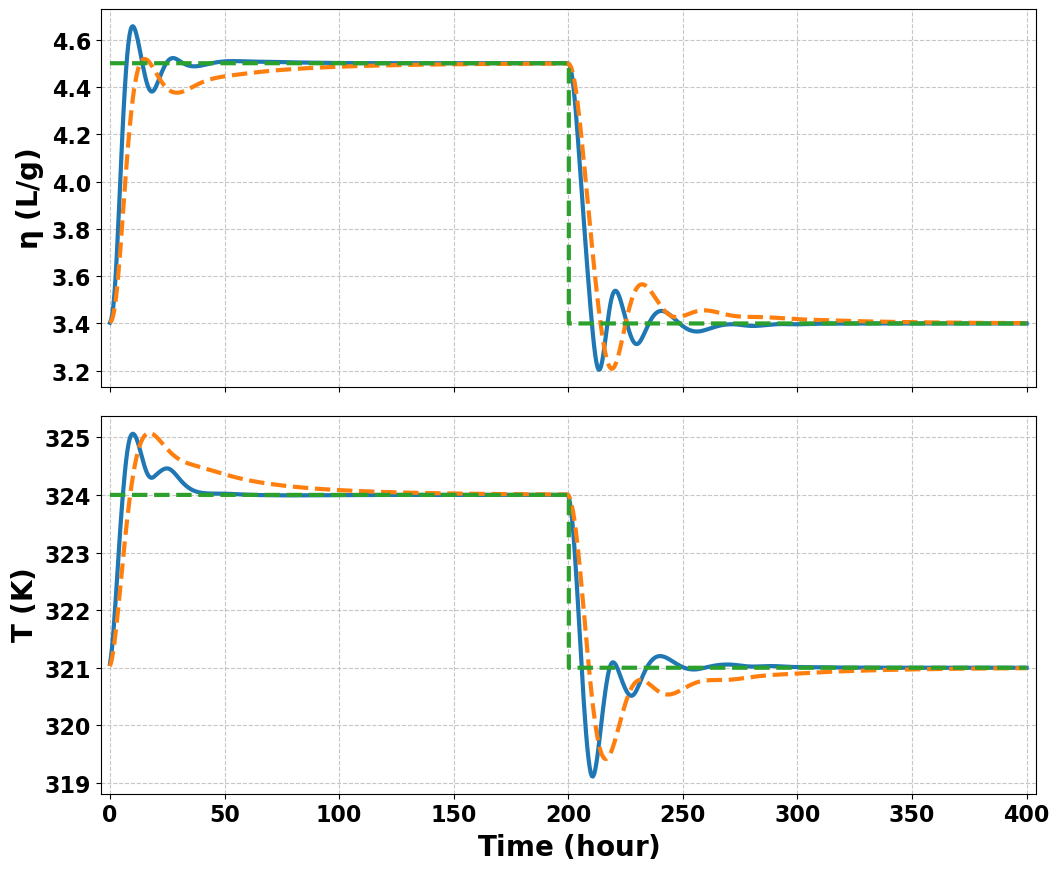

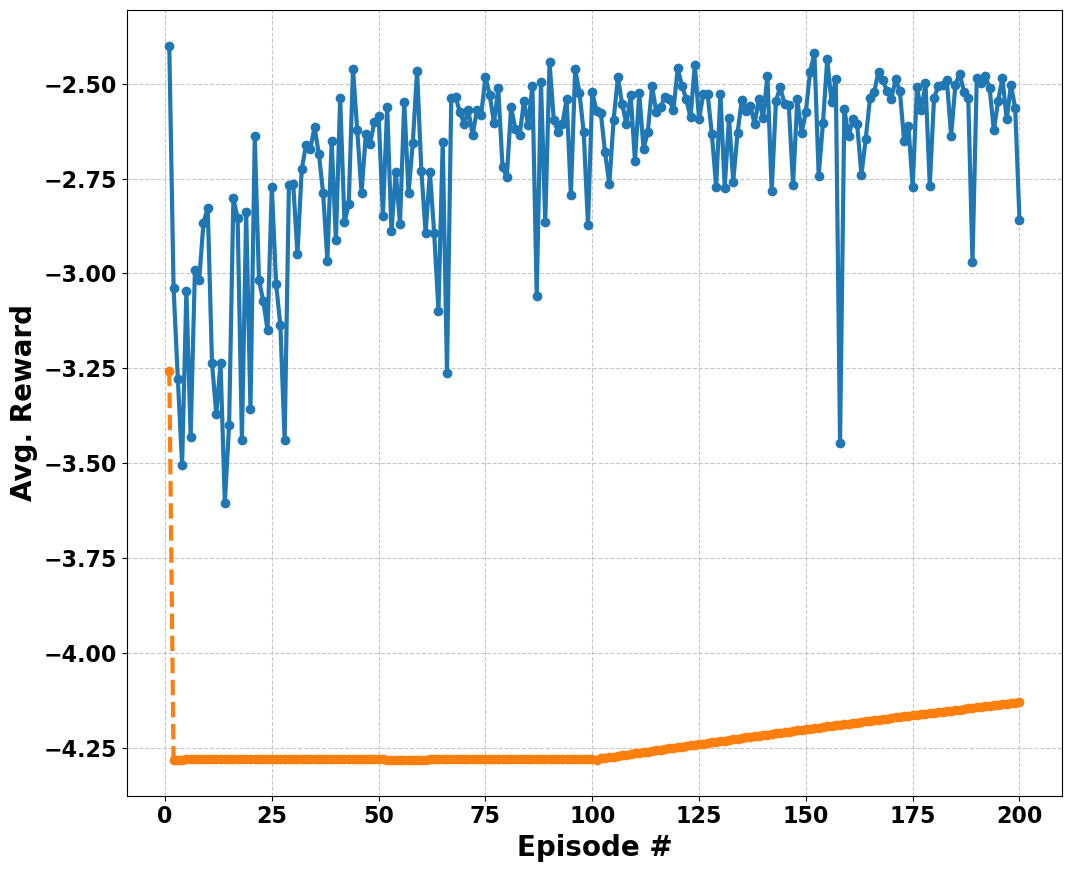

In [73]:
compare_mpc_rl_disturbance(y_system, y_mpc, y_sp, avg_rewards, avg_rewards_mpc, time_in_sub_episodes, delta_t)

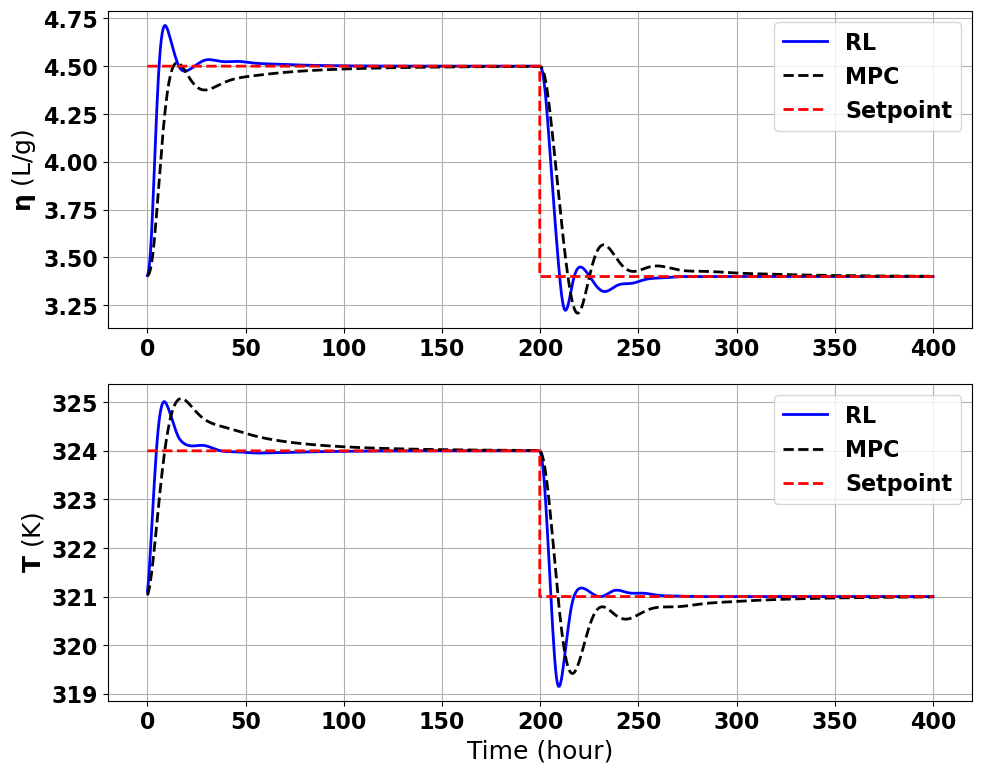

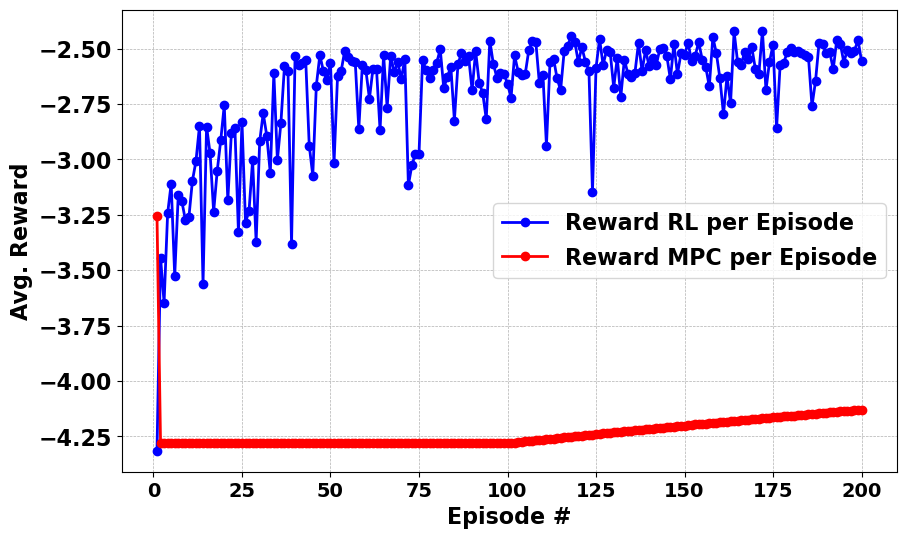

In [30]:
compare_mpc_rl_disturbance(y_system, y_mpc, y_sp, avg_rewards, avg_rewards_mpc, time_in_sub_episodes, delta_t)